In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step#1 : Read in our data
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# General info about the dataset
print(df.info())

# Check for missing values
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [5]:

    #from sklearn.preprocessing import LabelEncoder

    # Encode 'sex' and 'smoker'
    #label_encoder = LabelEncoder()
    #df['sex'] = label_encoder.fit_transform(df['sex'])  # female -> 0, male -> 1
    #df['smoker'] = label_encoder.fit_transform(df['smoker'])  # no -> 0, yes -> 1

    # One-Hot Encoding for 'region'
    #df = pd.get_dummies(df, columns=['region'], drop_first=True)  # Drop one to avoid dummy variable trap

    #print(df.head())


In [6]:

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['smoker'] = label_encoder.fit_transform(df['smoker'])  # no -> 0, yes -> 1
print(df.head())


   age     sex     bmi  children  smoker     region      charges
0   19  female  27.900         0       1  southwest  16884.92400
1   18    male  33.770         1       0  southeast   1725.55230
2   28    male  33.000         3       0  southeast   4449.46200
3   33    male  22.705         0       0  northwest  21984.47061
4   32    male  28.880         0       0  northwest   3866.85520


In [7]:
# Step#2 EDA
if False:
    sns.pairplot(df)

In [8]:
# Step#3 Divide data X and y label
#X = df.drop(["charges","sex","smoker","region"], axis=1)
X = df.drop(["charges","sex","region"], axis=1)
y = df["charges"]

In [9]:
X.shape

(1338, 4)

In [10]:
#from statistics import LinearRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [11]:
polynomial_convertor = PolynomialFeatures(degree=2,
                                          include_bias=False)

In [12]:
# polyX
poly_features = polynomial_convertor.fit_transform(X)

In [13]:
poly_features.shape

(1338, 14)

In [14]:
poly_features

array([[19.  , 27.9 ,  0.  , ...,  0.  ,  0.  ,  1.  ],
       [18.  , 33.77,  1.  , ...,  1.  ,  0.  ,  0.  ],
       [28.  , 33.  ,  3.  , ...,  9.  ,  0.  ,  0.  ],
       ...,
       [18.  , 36.85,  0.  , ...,  0.  ,  0.  ,  0.  ],
       [21.  , 25.8 ,  0.  , ...,  0.  ,  0.  ,  0.  ],
       [61.  , 29.07,  0.  , ...,  0.  ,  0.  ,  1.  ]])

In [15]:
poly_features[0]

array([ 19.  ,  27.9 ,   0.  ,   1.  , 361.  , 530.1 ,   0.  ,  19.  ,
       778.41,   0.  ,  27.9 ,   0.  ,   0.  ,   1.  ])

In [16]:
from sklearn.preprocessing import StandardScaler
if False:
    scaler = StandardScaler()
    poly_features = scaler.fit_transform(poly_features)  # Scale polynomial features

In [17]:
X_train, X_test, y_train,y_test = train_test_split(poly_features,
                                                    y,
                                                    test_size = 0.3,
                                                    random_state = 101)

In [18]:
type(X_train)

numpy.ndarray

In [19]:

model = LinearRegression(fit_intercept=True)

In [20]:
model.fit(X_train,y_train)

LinearRegression()

In [21]:
model.coef_

array([-2.01656585e+02,  5.79715064e+02,  4.85499127e+02, -9.69011723e+03,
        4.59133280e+00,  2.73249465e+00,  1.08863070e+01, -2.21448920e+01,
       -1.05954500e+01,  1.69444555e+00,  1.43972466e+03, -5.00448043e+01,
       -3.29695540e+02, -9.69011723e+03])

In [22]:
model.intercept_

np.float64(-3291.027987453768)

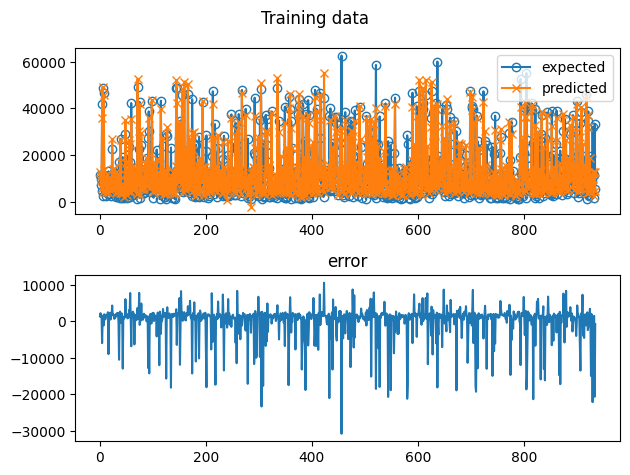

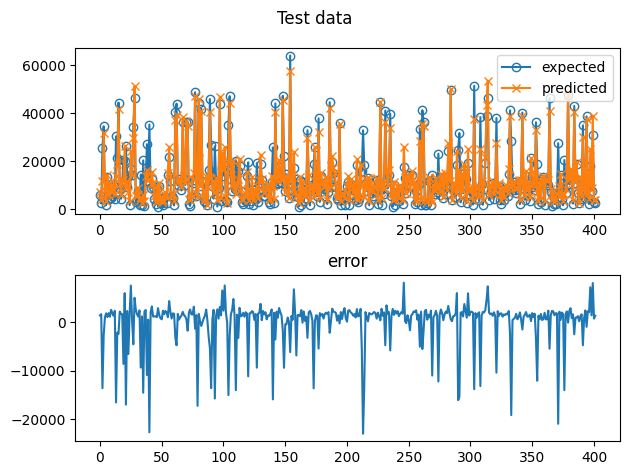

In [23]:
pred = model.predict(X_train)
expected = y_train.tolist()
plt.figure()
plt.subplot(2,1,1)
plt.plot(expected, marker='o', markerfacecolor='none')
plt.plot(pred, marker='x', markerfacecolor='none')
plt.legend(['expected', 'predicted'],loc='upper right')
plt.subplot(2,1,2)
plt.plot(pred-expected)
plt.title('error')
plt.suptitle('Training data')
plt.tight_layout()


pred = model.predict(X_test)
expected = y_test.to_list()
plt.figure()
plt.subplot(2,1,1)
plt.plot(expected, marker='o', markerfacecolor='none')
plt.plot(pred, marker='x', markerfacecolor='none')
plt.legend(['expected', 'predicted'],loc='upper right')
plt.subplot(2,1,2)
plt.plot(pred-expected)
plt.title('error')
plt.suptitle('Test data')
plt.tight_layout()

y_pred = pred


In [24]:

MAE = mean_absolute_error(y_test,y_pred)
print(MAE)

2820.834247125995


In [25]:
RMSE = mean_squared_error(y_test,y_pred)**0.5
print(RMSE)

4663.738085878273


In [26]:

r2 = r2_score(y_test,y_pred)
print(r2)

0.8451673509830628


In [27]:
tolerance = RMSE/y.mean()
tolerance

np.float64(0.35143855957989967)

In [28]:
# We need to deploy our model
final_poly_2_model = LinearRegression()
final_ploy_convertor = PolynomialFeatures(degree=2,include_bias=False)
poly_X = final_ploy_convertor.fit_transform(X)
final_poly_2_model.fit(poly_X,y)

LinearRegression()

In [29]:
# Let's compare coef_ for final and trained model
final_poly_2_model.coef_

array([-1.00743701e+02,  4.97810097e+02,  1.32657335e+03, -9.83229452e+03,
        3.94239109e+00,  1.69281991e+00, -1.09903048e+00, -2.70521085e+00,
       -8.85430127e+00, -3.24990619e+00,  1.43505973e+03, -1.30751623e+02,
       -3.97975286e+02, -9.83229452e+03])

In [30]:
model.coef_

array([-2.01656585e+02,  5.79715064e+02,  4.85499127e+02, -9.69011723e+03,
        4.59133280e+00,  2.73249465e+00,  1.08863070e+01, -2.21448920e+01,
       -1.05954500e+01,  1.69444555e+00,  1.43972466e+03, -5.00448043e+01,
       -3.29695540e+02, -9.69011723e+03])

In [31]:
# We need before deploy our model do Bias-Variation trade off as next : 

from sklearn.linear_model import LinearRegression


train_rmse_errors=[]
test_rmse_errors =[]
for d in range(1,11): # we over shooting her max used to be 6
    #create related poly_convertor
    polynomial_convertor = PolynomialFeatures(degree=d,include_bias=False)
    # create our Poly X
    poly_features = polynomial_convertor.fit_transform(X)
    # train_test_split
    X_train, X_test, y_train, y_test = train_test_split(poly_features, 
                                                    y, 
                                                    test_size=0.3, 
                                                    random_state=101)
    # train related model
    model = LinearRegression(fit_intercept=True)
    model.fit(X_train,y_train)
    # Calculate RMSE for train and test part
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_RMSE = mean_squared_error(y_train,train_pred)**0.5
    test_RMSE = mean_squared_error(y_test,test_pred)**0.5
    # adding related errors to our lists
    train_rmse_errors.append(train_RMSE)
    test_rmse_errors.append(test_RMSE)


In [32]:
train_rmse_errors

[6174.112077726081,
 4867.179419396012,
 4760.792548993228,
 4626.570427655438,
 4486.380475359281,
 4389.51437208853,
 4302.090904899462,
 4224.522558594018,
 4185.070578512194,
 4175.914874922415]

In [33]:
test_rmse_errors

[5803.288437295531,
 4663.738085878273,
 4732.268559839043,
 4869.007500590285,
 4856.998226045364,
 5012.381807957908,
 9500.578261721323,
 12909.319671741005,
 19229.18884774853,
 17436.470653370758]

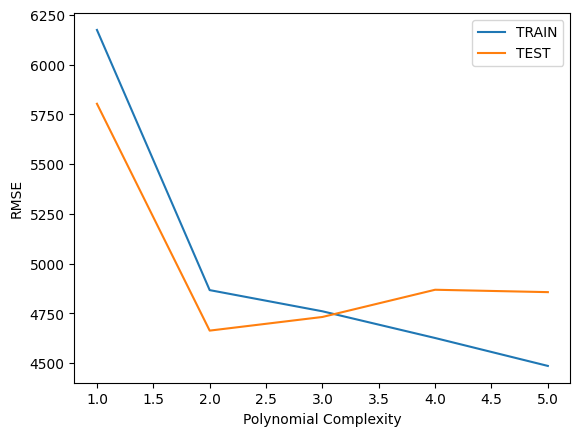

In [34]:
plt.plot(range(1,6),train_rmse_errors[:5], label = "TRAIN")
plt.plot(range(1,6),test_rmse_errors[:5],label = "TEST")
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

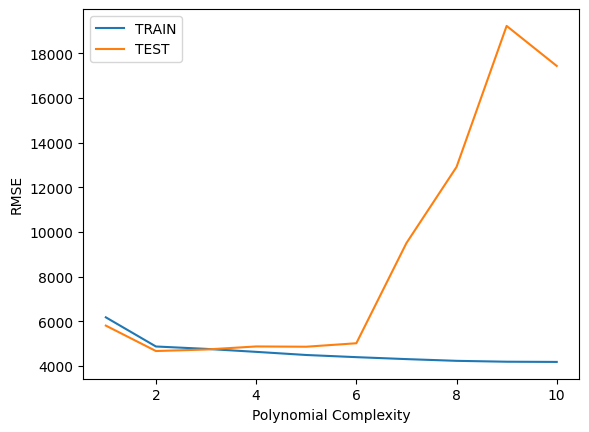

In [35]:
plt.plot(range(1,11),train_rmse_errors, label = "TRAIN")
plt.plot(range(1,11),test_rmse_errors,label = "TEST")
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

In [36]:
# Deploy our model
final_poly_3_model = LinearRegression()
final_ploy_convertor_3 = PolynomialFeatures(degree=3,include_bias=False)
poly_X = final_ploy_convertor_3.fit_transform(X)
final_poly_3_model.fit(poly_X,y)

LinearRegression()

In [37]:
from joblib import dump , load
dump(final_ploy_convertor_3,"poly_d3_conv_20250117.joblib")
dump(final_poly_3_model,"model_d3_poly_20250117.joblib")

['model_d3_poly_20250117.joblib']

In [38]:
loaded_convertor = load("poly_d3_conv_20250117.joblib")
loaded_model = load("model_d3_poly_20250117.joblib")

In [39]:
campaign = [[19,27.9,0,1]]# real value was 16884.924
sales_prediction = loaded_model.predict(loaded_convertor.fit_transform(campaign))
print(f"for {campaign} sales will be = {sales_prediction}")

for [[19, 27.9, 0, 1]] sales will be = [22714.68444461]


In [40]:
import tkinter as tk
# To load the trained model
from joblib import load


# Load the trained model
loaded_convertor = load("poly_d3_conv_20250117.joblib")
loaded_model = load("model_d3_poly_20250117.joblib")

def predict_price():
    # Get input values
    age = int(age_entry.get())
    bmi = float(bmi_entry.get())
    children = int(children_entry.get())
    # Convert Yes/No to 1/0
    smoker = 1 if smoker_var.get() == 'Yes' else 0  

    # Prepare the input array (example assumes preprocessing is already done)
    inputs = [[age, bmi, children, smoker]]
    sales_prediction = loaded_model.predict(loaded_convertor.fit_transform(inputs))[0]


    # Show the result
    result_label.config(text=f"Predicted Price: ${sales_prediction:.2f}")

# Create the app window
app = tk.Tk()
app.title("Insurance Price Predictor")
app.geometry("400x300")  # Set the window size

# Add column weight for better alignment
app.grid_columnconfigure(0, weight=1)
app.grid_columnconfigure(1, weight=1)

# Add input fields with padding
tk.Label(app, text="Age:").grid(row=0, column=0, padx=10, pady=5)
age_entry = tk.Entry(app)
age_entry.grid(row=0, column=1, padx=10, pady=5)

tk.Label(app, text="BMI:").grid(row=1, column=0, padx=10, pady=5)
bmi_entry = tk.Entry(app)
bmi_entry.grid(row=1, column=1, padx=10, pady=5)

tk.Label(app, text="Children:").grid(row=2, column=0, padx=10, pady=5)
children_entry = tk.Entry(app)
children_entry.grid(row=2, column=1, padx=10, pady=5)

tk.Label(app, text="Smoker (Yes/No):").grid(row=3, column=0, padx=10, pady=5)
smoker_var = tk.StringVar(value="No")
tk.Entry(app, textvariable=smoker_var).grid(row=3, column=1, padx=10, pady=5)

# Add predict button
tk.Button(app, text="Predict", command=predict_price).grid(row=4, column=0, columnspan=2, pady=10)

# Add result label
result_label = tk.Label(app, text="")
result_label.grid(row=5, column=0, columnspan=2, pady=10)

# Run the app
app.mainloop()
